In [103]:
# imports and constants

# !pip install tqdm

import numpy as np
import os
from tqdm import tqdm
import matplotlib.pyplot as plt
import pandas as pd

In [104]:
# loading image and mask

IMAGE_PATH = "../data/processed/images/ngc628_f770w_norm.npy"
MASK_PATH = "../data/processed/masks/ngc628_f770w_norm_mask.npy"
OUTPUT_DIR = "../data/processed/patches"
# DATA_DIR = "../data/processed"

os.makedirs(OUTPUT_DIR, exist_ok=True)

metadata_path = os.path.join(OUTPUT_DIR, "patch_metadata.csv")

PATCH_SIZE = 256
STRIDE = 128  # liitle overlap 

# THRESHOLD = 0.05
LOW_THRESHOLD = 0.001   # negative patch threshold
HIGH_THRESHOLD = 0.05   # positive patch threshold


In [105]:
# validation and normalization

image = np.load(IMAGE_PATH).astype(np.float32)
mask = np.load(MASK_PATH).astype(np.float32)

# Ensuring binary mask
mask = (mask > 0).astype(np.float32)

In [106]:
# small sanity check
print("Image shape:", image.shape, "dtype:", image.dtype, "min/max:", image.min(), image.max())
print("Mask shape:", mask.shape, "dtype:", mask.dtype, "min/max:", mask.min(), mask.max())
print("Bubble pixels:", int(mask.sum()))

unique_vals = np.unique(mask)
print("Mask unique values:", unique_vals[:10])

Image shape: (1177, 2380) dtype: float32 min/max: 0.0 1.0
Mask shape: (1177, 2380) dtype: float32 min/max: 0.0 1.0
Bubble pixels: 572320
Mask unique values: [0. 1.]


In [107]:
assert image.shape == mask.shape, "Image and mask must have the same height and width."
assert image.ndim == 2, "Expected image to be a 2D array."
assert mask.ndim == 2, "Expected mask to be a 2D array."
assert mask.max() <= 1 and mask.min() >= 0, "Mask must be binary or in [0, 1]."
# assert mask.sum() > 0, "Mask contains no bubble pixels"

In [108]:
image = image.astype(np.float32)

# for Training image
denom = image.max() - image.min()
if denom > 0:
    image = (image - image.min()) / denom
else:
    image = np.zeros_like(image)

In [109]:
# Spatial train/validation split disabled for now.
# # spatial separation
#
# image_height, image_width = image.shape
#
# validation_boundary = int(image_width * 0.80)
#
# print("Image width:", image_width)
# print("Validation begins at x =", validation_boundary)

In [110]:
def extract_patches(
    image,
    mask,
    patch_size=256,
    stride=128,
    low_threshold=0.001,
    high_threshold=0.05
):
    H, W = image.shape

    pos_patches = []
    weak_patches = []
    neg_patches = []

    for y_start in range(
        0,
        H - patch_size + 1,
        stride
    ):
        for x_start in range(
            0,
            W - patch_size + 1,
            stride
        ):
            image_patch = image[
                y_start:y_start + patch_size,
                x_start:x_start + patch_size
            ]

            mask_patch = mask[
                y_start:y_start + patch_size,
                x_start:x_start + patch_size
            ]

            bubble_ratio = mask_patch.mean()

            patch_record = {
                "image": image_patch,
                "mask": mask_patch,
                "y_start": y_start,
                "x_start": x_start,
                "bubble_ratio": bubble_ratio,
            }

            if bubble_ratio >= high_threshold:
                patch_record["category"] = "positive"
                pos_patches.append(patch_record)

            elif bubble_ratio >= low_threshold:
                patch_record["category"] = "weak"
                weak_patches.append(patch_record)

            else:
                patch_record["category"] = "negative"
                neg_patches.append(patch_record)

    return pos_patches, weak_patches, neg_patches

In [111]:
SEED = 42
np.random.seed(SEED)

pos, weak, neg = extract_patches(image, mask, patch_size=PATCH_SIZE, stride=STRIDE, low_threshold=LOW_THRESHOLD, high_threshold=HIGH_THRESHOLD)

print(f"Positive patches: {len(pos)}")
print(f"Weak patches: {len(weak)}")
print(f"Negative patches: {len(neg)}")

Positive patches: 117
Weak patches: 9
Negative patches: 10


In [112]:
np.random.shuffle(pos)
np.random.shuffle(weak)
np.random.shuffle(neg)

n_strong = len(pos)
n_weak = min(len(weak), n_strong)
n_neg = min(len(neg), n_strong // 2)

dataset = pos + weak[:n_weak] + neg[:n_neg]

np.random.shuffle(dataset)

print(f"Dataset: {len(dataset)}")

Dataset: 136


In [113]:
X = np.array(
    [record["image"] for record in dataset],
    dtype=np.float32
)

Y = np.array(
    [record["mask"] for record in dataset],
    dtype=np.float32
)

X = X[..., np.newaxis]
Y = Y[..., np.newaxis]

print("X shape:", X.shape)
print("Y shape:", Y.shape)

assert X.shape == Y.shape
assert X.ndim == 4
assert Y.ndim == 4

X shape: (136, 256, 256, 1)
Y shape: (136, 256, 256, 1)


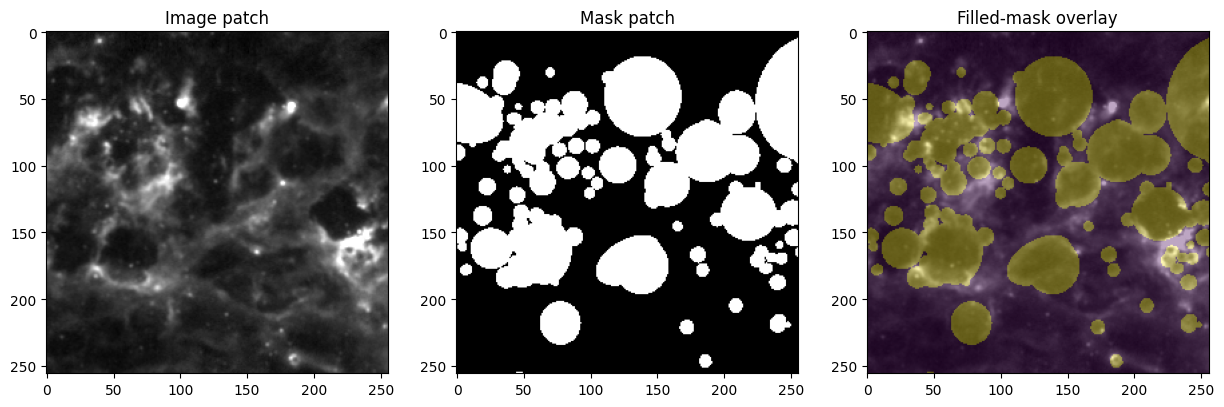

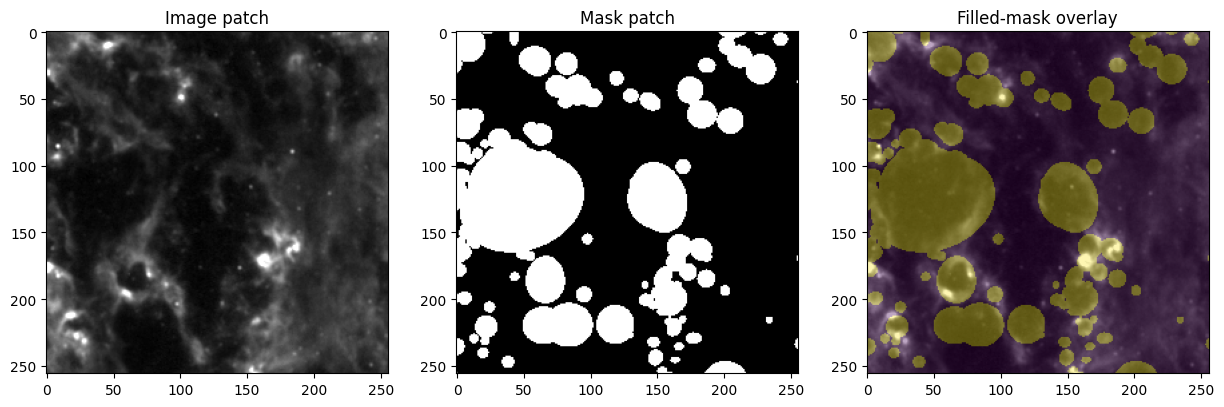

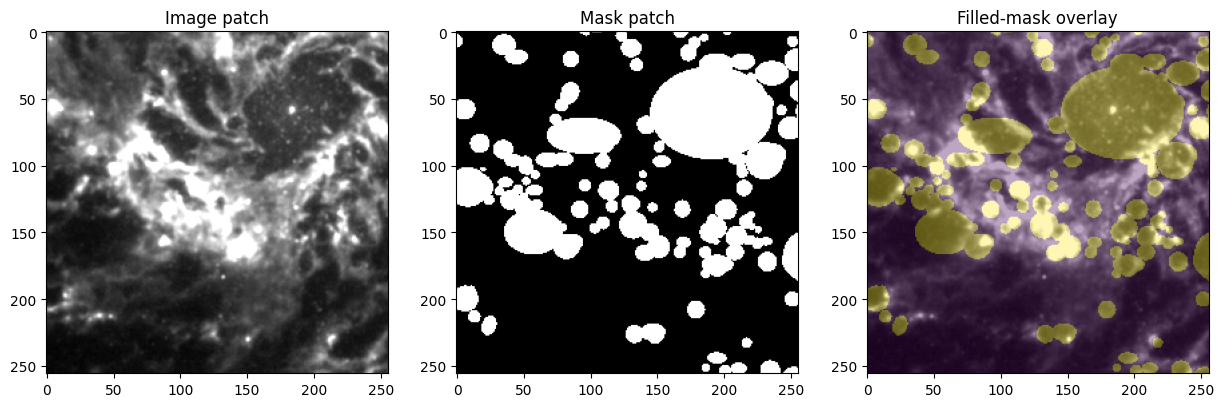

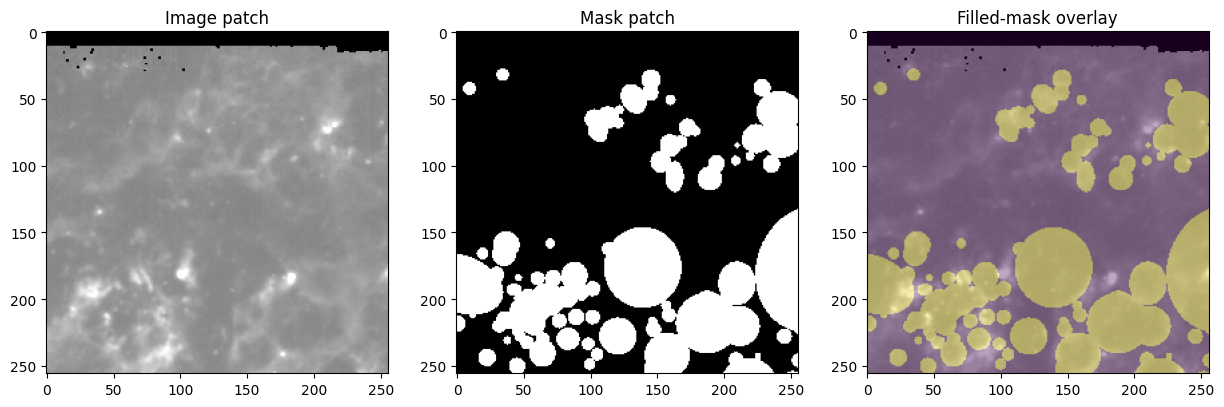

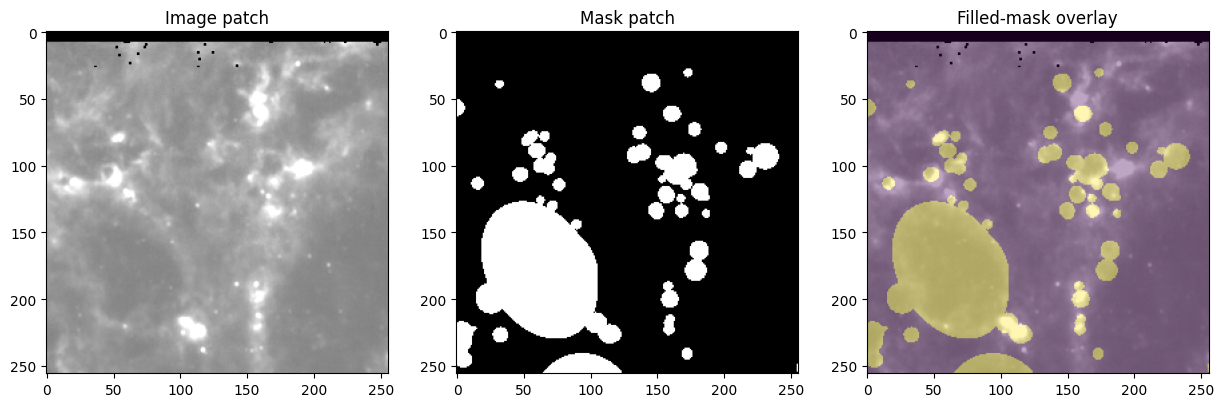

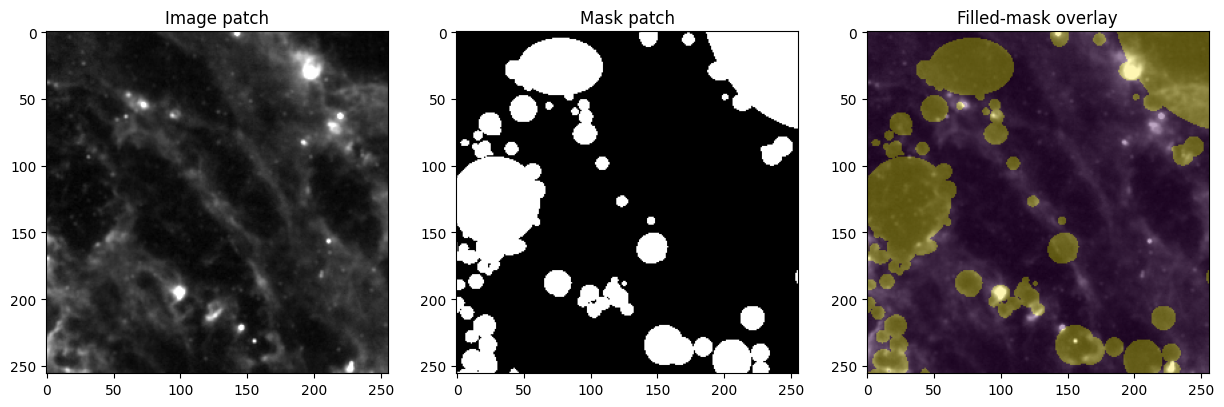

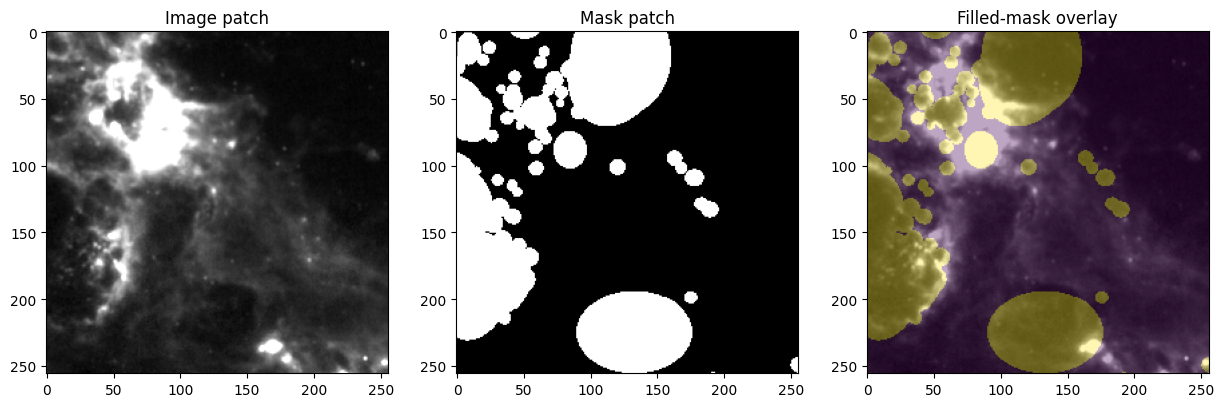

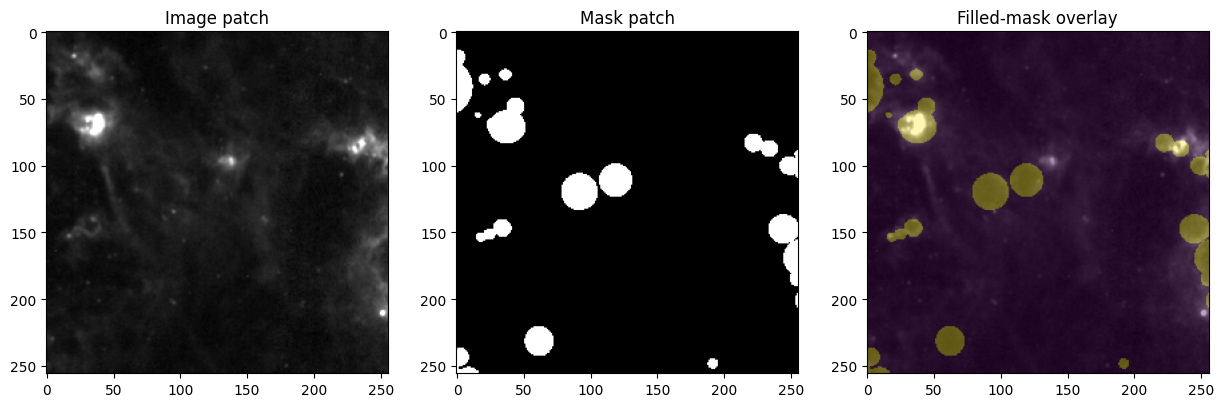

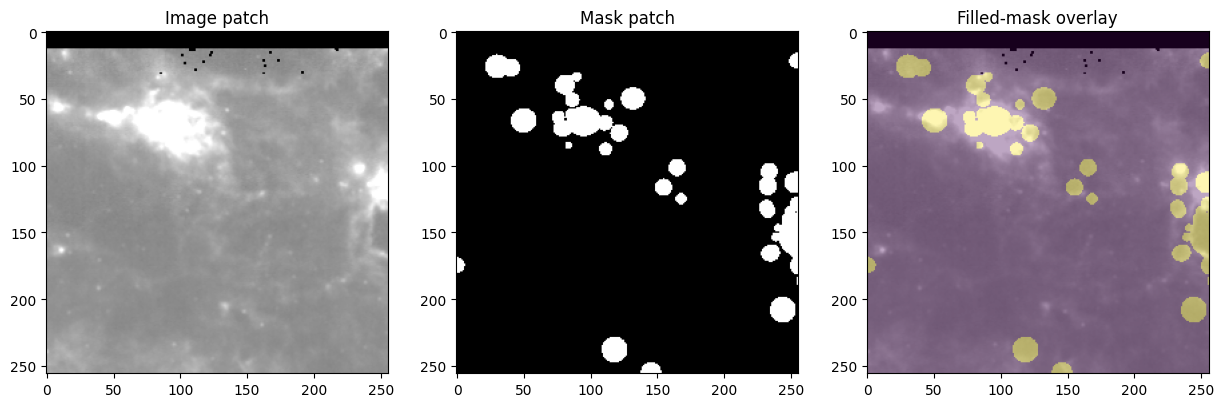

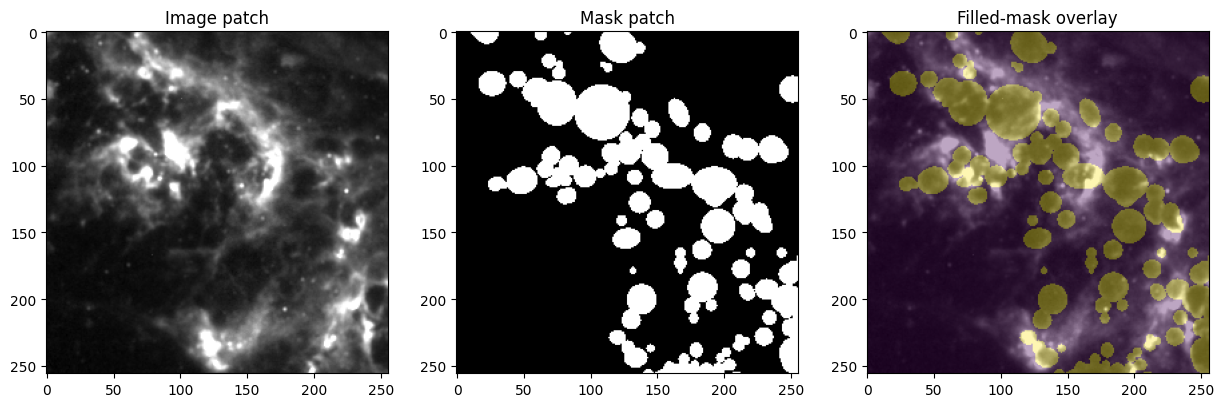

In [114]:
# sanity check

for i in range(10):
    # fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    plt.figure(figsize=(15,6))

    plt.subplot(1,3,1)
    plt.imshow(X[i].squeeze(), cmap="gray")
    plt.title("Image patch")

    plt.subplot(1,3,2)
    plt.imshow(Y[i].squeeze(), cmap="gray")
    plt.title("Mask patch")

    plt.subplot(1,3,3)
    plt.imshow(X[i].squeeze(), cmap="gray")
    plt.imshow(Y[i].squeeze(), alpha=0.35)
    plt.title("Filled-mask overlay")
    
    plt.show()


In [117]:
# Spatial train/validation split disabled for now.
# def assign_spatial_split(
#     metadata,
#     patch_size,
#     validation_boundary,
#     gap=None
# ):
#     metadata = metadata.copy()
#
#     if gap is None:
#         gap = patch_size
#
#     # Training patches must finish this far before validation begins.
#     train_limit = validation_boundary - gap
#
#     def classify(row):
#         x_start = int(row["x_start"])
#         x_end = x_start + patch_size
#
#         if x_end <= train_limit:
#             return "train"
#
#         if x_start >= validation_boundary:
#             return "validation"
#
#         return "excluded_buffer"
#
#     metadata["split"] = metadata.apply(
#         classify,
#         axis=1
#     )
#
#     return metadata


In [118]:
metadata = pd.DataFrame([
    {
        "patch_id": patch_id,
        "y_start": record["y_start"],
        "x_start": record["x_start"],
        "category": record["category"],
        "bubble_ratio": record["bubble_ratio"],
    }
    for patch_id, record in enumerate(dataset)
])

metadata.head()


,patch_id,y_start,x_start,category,bubble_ratio
0,0,128,1408,positive,0.379532
1,1,640,1536,positive,0.310669
2,2,512,1152,positive,0.301697
3,3,0,1408,positive,0.309906
4,4,0,768,positive,0.193542


In [119]:
# metadata = assign_spatial_split(
#     metadata,
#     patch_size=PATCH_SIZE,
#     validation_boundary=validation_boundary,
#     gap=PATCH_SIZE
# )

# print(metadata["split"].value_counts())

In [120]:

assert len(metadata) == len(X), (
    f"Metadata has {len(metadata)} rows, "
    f"but X has {len(X)} patches."
)

assert len(metadata) == len(Y), (
    f"Metadata has {len(metadata)} rows, "
    f"but Y has {len(Y)} patches."
)

assert metadata["patch_id"].is_unique, (
    "Metadata contains duplicate patch IDs."
)

assert np.array_equal(
    metadata["patch_id"].to_numpy(),
    np.arange(len(X))
), "Patch IDs do not correspond to the X/Y array positions."

print("Number of patches:", len(X))
print("Number of metadata rows:", len(metadata))
print("Unique patch IDs:", metadata["patch_id"].nunique())

Number of patches: 136
Number of metadata rows: 136
Unique patch IDs: 136


In [121]:
# Spatial train/validation split disabled for now.
# image_height, image_width = image.shape
#
# validation_boundary = int(image_width * 0.80)
#
# metadata = assign_spatial_split(
#     metadata=metadata,
#     patch_size=PATCH_SIZE,
#     validation_boundary=validation_boundary,
#     gap=PATCH_SIZE
# )
#
# print("Image width:", image_width)
# print("Validation boundary:", validation_boundary)
# print()
# print(metadata["split"].value_counts())

In [122]:
# Spatial train/validation split disabled for now.
# def rectangles_overlap(a, b, patch_size):
#     a_x1 = int(a.x_start)
#     a_y1 = int(a.y_start)
#     a_x2 = a_x1 + patch_size
#     a_y2 = a_y1 + patch_size
#
#     b_x1 = int(b.x_start)
#     b_y1 = int(b.y_start)
#     b_x2 = b_x1 + patch_size
#     b_y2 = b_y1 + patch_size
#
#     horizontal_overlap = (
#         max(a_x1, b_x1) < min(a_x2, b_x2)
#     )
#
#     vertical_overlap = (
#         max(a_y1, b_y1) < min(a_y2, b_y2)
#     )
#
#     return horizontal_overlap and vertical_overlap

In [123]:
# Spatial train/validation split disabled for now.
# def check_cross_split_overlap(
#     metadata,
#     patch_size,
#     required_gap=0
# ):
#     train = metadata[
#         metadata["split"] == "train"
#     ]
#
#     validation = metadata[
#         metadata["split"] == "validation"
#     ]
#
#     excluded = metadata[
#         metadata["split"] == "excluded_buffer"
#     ]
#
#     print("Training patches:", len(train))
#     print("Validation patches:", len(validation))
#     print("Excluded patches:", len(excluded))
#
#     if train.empty:
#         print("FAILED: No training patches were created.")
#         return False
#
#     if validation.empty:
#         print("FAILED: No validation patches were created.")
#         return False
#
#     overlapping_pairs = []
#
#     for train_row in train.itertuples(index=False):
#         for validation_row in validation.itertuples(
#             index=False
#         ):
#             if rectangles_overlap(
#                 train_row,
#                 validation_row,
#                 patch_size
#             ):
#                 overlapping_pairs.append(
#                     (
#                         train_row.patch_id,
#                         validation_row.patch_id
#                     )
#                 )
#
#     train_right_edge = (
#         train["x_start"] + patch_size
#     ).max()
#
#     validation_left_edge = validation["x_start"].min()
#
#     actual_gap = (
#         validation_left_edge - train_right_edge
#     )
#
#     print("Cross-split overlapping pairs:",
#           len(overlapping_pairs))
#     print("Training right edge:",
#           train_right_edge)
#     print("Validation left edge:",
#           validation_left_edge)
#     print("Actual horizontal gap:",
#           actual_gap)
#
#     if overlapping_pairs:
#         print(
#             "FAILED: Training and validation patches overlap."
#         )
#         print(
#             "Example overlaps:",
#             overlapping_pairs[:10]
#         )
#         return False
#
#     if actual_gap < required_gap:
#         print(
#             f"FAILED: Required gap is {required_gap}, "
#             f"but actual gap is {actual_gap}."
#         )
#         return False
#
#     print(
#         "PASSED: Training and validation regions "
#         "are spatially separated."
#     )
#
#     return True

In [124]:
# Spatial train/validation split disabled for now.
# spatial_split_valid = check_cross_split_overlap(
#     metadata,
#     patch_size=PATCH_SIZE,
#     required_gap=PATCH_SIZE
# )

In [125]:
metadata.to_csv(metadata_path, index=False)

print("Saved metadata to:", metadata_path)


Saved metadata to: ../data/processed/patches/patch_metadata.csv


In [126]:

# full_image = np.load(IMAGE_PATH)
# full_mask = np.load(MASK_PATH)
full_image = image
full_mask = mask


def verify_patch_reconstruction(
    X,
    Y,
    full_image,
    full_mask,
    metadata,
    atol=1e-7
):
    failures = []

    for row in metadata.itertuples(index=False):
        patch_id = int(row.patch_id)
        y_start = int(row.y_start)
        x_start = int(row.x_start)

        reconstructed_image = full_image[
            y_start:y_start + PATCH_SIZE,
            x_start:x_start + PATCH_SIZE
        ]

        reconstructed_mask = full_mask[
            y_start:y_start + PATCH_SIZE,
            x_start:x_start + PATCH_SIZE
        ]

        stored_image = X[patch_id, ..., 0]
        stored_mask = Y[patch_id, ..., 0]

        image_matches = np.allclose(
            stored_image,
            reconstructed_image,
            atol=atol
        )

        mask_matches = np.array_equal(
            stored_mask,
            reconstructed_mask
        )

        if not image_matches or not mask_matches:
            failures.append({
                "patch_id": patch_id,
                "image_matches": image_matches,
                "mask_matches": mask_matches,
                "y_start": y_start,
                "x_start": x_start,
            })

    print("Patches checked:", len(metadata))
    print("Failures:", len(failures))

    if failures:
        print("First failures:")
        for failure in failures[:10]:
            print(failure)
        return False

    print("Every stored patch matches its original image and mask region.")
    return True



In [127]:
patch_reconstruction_valid = verify_patch_reconstruction(
    X,
    Y,
    full_image,
    full_mask,
    metadata
)

Patches checked: 136
Failures: 0
Every stored patch matches its original image and mask region.


In [128]:
# Spatial train/validation split disabled for now.
# train_ids = metadata.loc[
#     metadata["split"] == "train",
#     "patch_id"
# ].to_numpy(dtype=int)
#
# validation_ids = metadata.loc[
#     metadata["split"] == "validation",
#     "patch_id"
# ].to_numpy(dtype=int)
#
# excluded_ids = metadata.loc[
#     metadata["split"] == "excluded_buffer",
#     "patch_id"
# ].to_numpy(dtype=int)

In [129]:
# Spatial train/validation split disabled for now.
# X_train = X[train_ids]
# Y_train = Y[train_ids]
#
# X_validation = X[validation_ids]
# Y_validation = Y[validation_ids]
#
# print("X_train:", X_train.shape)
# print("Y_train:", Y_train.shape)
# print("X_validation:", X_validation.shape)
# print("Y_validation:", Y_validation.shape)

In [130]:
os.makedirs(OUTPUT_DIR, exist_ok=True)

np.save(os.path.join(OUTPUT_DIR, "X.npy"), X)
np.save(os.path.join(OUTPUT_DIR, "Y.npy"), Y)

print("Saved complete patch datasets.")

Saved complete patch datasets.


In [131]:
# Spatial train/validation split disabled for now.
# assert spatial_split_valid, (
#     "Spatial split verification failed."
# )
#
# assert len(train_ids) > 0, (
#     "No training patches were created."
# )
#
# assert len(validation_ids) > 0, (
#     "No validation patches were created."
# )
#
# assert len(
#     np.intersect1d(train_ids, validation_ids)
# ) == 0, (
#     "The same patch ID appears in both "
#     "training and validation sets."
# )
#
# assert len(train_ids) + len(validation_ids) + len(excluded_ids) == len(X), (
#     "Some patches were not assigned exactly one split."
# )
#
# assert X_train.shape == Y_train.shape
# assert X_validation.shape == Y_validation.shape
#
# print("Final spatial-split assertions passed.")

In [132]:
# Spatial train/validation split disabled for now.
# print(
#     pd.crosstab(
#         metadata["split"],
#         metadata["category"]
#     )
# )

In [133]:
# Spatial train/validation split disabled for now.
# validation_foreground = Y_validation.mean(
#     axis=(1, 2, 3)
# )
#
# print(
#     "Validation foreground ratios:",
#     np.round(validation_foreground, 4)
# )
#
# print(
#     "Empty validation masks:",
#     np.sum(validation_foreground == 0)
# )

In [134]:
# Spatial train/validation split disabled for now.
#
# np.save(
#     os.path.join(OUTPUT_DIR, "X_train.npy"),
#     X_train
# )
#
# np.save(
#     os.path.join(OUTPUT_DIR, "Y_train.npy"),
#     Y_train
# )
#
# np.save(
#     os.path.join(OUTPUT_DIR, "X_validation.npy"),
#     X_validation
# )
#
# np.save(
#     os.path.join(OUTPUT_DIR, "Y_validation.npy"),
#     Y_validation
# )
#
# print("Saved spatially separated datasets.")